In [5]:
from IPython.display import HTML

HTML("""
<style>

a[href^="http://"],
a[href^="https://"] {
    color: blue !important;
}

/* stil za sve tabele */
table {
    margin-left: auto !important;
    margin-right: auto !important;
    width: auto !important;
    max-width: none !important;
    table-layout: auto !important;
    border-collapse: collapse !important;
    font-family: "Segoe UI", "Calibri", sans-serif !important;
    font-size: 12px !important;
}

th, td {
    padding: 8px 20px !important;
}

/* дебља, јача линија испод заглавља */
tr:first-child th {
    border-bottom: 2px solid #222 !important;
}

/* тања, светлија линија испод последњег реда */
tr:last-child td {
    border-bottom: 1px solid #aaa !important;
}

</style>
""")

# Algoritam k najbližih suseda

## Uvod

Algoritam $k$-najbližih suseda (engl. $k$-nearest neighbors, KNN) predstavlja jedan od najjednostavnijih i najčešće korišćenih metoda nadgledanog učenja. Osnovni princip KNN algoritma klasifikacije zasniva se na određivanju pripadnosti posmatrane instance na osnovu njegove prostorne bliskosti sa već poznatim primerima, zapravo algoritam pronalazi $k$ najbližih primera iz skupa za učenje, koje su mu najbliže u smislu neke izabrane metrike, i posmatranoj instanci pridružuje klasu koja se najčešće javlja medu tih $k$ najbližih suseda. 

Osnovna pretpostavka ovog pristupa je da tačke koje su prostorno bliske ujedno pripadaju istoj ili sličnoj grupi. Pored klasifikacije, ovaj metod se uspešno primenjuje i u regresionim zadacima.  U slučaju regresije, algoritam posmatra numeričke vrednosti izlazne promenljive kod $k$ najbližih instanci i predviđena vrednost ciljnog atributa izračunava kao aritmetičku sredinu najbližih instanci. Ovaj algoritam pripada grupi modela zasnovanih na instancama (engl. Instance-based), jer ne gradi eksplicitnu matematičku formulu ili skup pravila iz podataka, već pamti primere (engl. instance) iz skupa za trening i na osnovu njih donosi odluke o klasifikaciji novih primera.

> Najjednostavnije rečeno, KNN funkcioniše po principu „reci mi s kim se družiš, pa ću ti reći ko si“ ili „reci mi ko su ti najbliži susedi, pa ću ti reći kojoj klasi pripadaš“, jer odluku donosi na osnovu osobina i oznaka najbližih podataka u prostoru obeležja.
> 
---

Ovaj algoritam se definiše kao neparametarski, što znači da ne pravi pretpostavke o raspodeli podataka. Broj
suseda $k$ predstavlja ključni hiperparametar modela. Za razliku od običnih parametara koje algoritam
samostalno izračunava tokom procesa obuke, hiperparametre mi zadajemo pre početka učenja. Pravilnim
podešavanjem vrednosti $k$ postiže se optimalan balans između tačnosti na poznatim podacima i sposobnosti
uopštavanja (generalizacije) na nove, neviđene primere.

#### Primer iz prakse: Optimizacija logističkih resursa pomoću KNN algoritma

U jednoj logističkoj kompaniji svakodnevno je potrebno odrediti optimalan broj vozila koja se šalju u različite delove grada, kako bi se minimizovali troškovi uz istovremeno ispunjenje svih zahteva kupaca. Odluke se donose na osnovu istorijskih podataka koji sadrže informacije o prethodnim radnim danima. Svaki pojedinačni dan prikazan je u formi vektora karakteristika koji sadrži sledeće atribute: dan u nedelji, vremenske uslove (kiša, sneg ili sunčano), ukupan broj primljenih porudžbina i saobraćajne parametre (poput nivoa zagušenja), dok je ciljna promenljiva optimalan broj angažovanih vozila zabeležen tog specifičnog dana. Na osnovu ovih vektora, algoritam meri sličnost nove situacije sa podacima iz prošlosti. Svaka karakteristika (poput vremena ili gužve) posmatra se kao jedna koordinata, pa se podaci prikazuju kao tačke u prostoru i izračunava se njihovu udaljenost. Kada se u sistem unese novi radni dan (npr. kišni utorak sa velikim brojem porudžbina i saobraćajnim gužvama), algoritam k-najbližih suseda automatski generiše predviđanje kroz sledeće tri ključne faze:


1. **Pronalaženje najsličnijih primera (Identifikacija suseda)** Algoritam analizira bazu podataka kako bi identifikovao $k$ istorijskih dana čije karakteristike (vreme, gužva, broj porudžbina) matematički najviše odgovaraju trenutnim uslovima.

2. **Analiza odabranih suseda** Sistem pristupa podacima o broju vozila koja su bila angažovana tokom tih $k$ identifikovanih, najsličnijih dana iz prošlosti.

3. **Izračunavanje konačnog ishoda (Predviđanje)** Na osnovu vrednosti dobijenih od suseda, algoritam generiše finalnu procenu. To se postiže izračunavanjem **aritmetičke sredine** (kod regresije, za dobijanje tačnog broja vozila) ili određivanjem **najučestalije kategorije** (kod klasifikacije).

:::{admonition} Ključni aspekti konfiguracije KNN algoritma
:class: note

- Izbor metrike udaljenosti: Na koji način ćemo kvantifikovati sličnost između instanci? Izbor metrike (npr. Euklidska, Menhetn ili Minkovski udaljenost) zavisi od prirode podataka.
- Strategija agregacije: Kod klasifikacije se najčešće koristi glasanje većine (engl. majority voting), dok se kod regresije izračunava aritmetička sredina njihovih vrednosti.
- Ponderisanje značaja instanci: Da li sve instance treba da imaju podjednak uticaj na konačnu odluku? U naprednijim pristupima, veći uticaj u donošenju odluke imaju instance koje su prostorno bliže posmatranoj tački, dok one udaljenije instance imaju manji značaj u procesu odlučivanja.
- Optimizacija parametra $k$: Koliki je optimalan broj suseda koje treba razmatrati? Pronalaženje prave vrednosti parametra $k$ ključno je za postizanje balansa između stabilnosti modela i njegove osetljivosti na bitne lokalne promene u podacima.

:::

#### Metrike udaljenosti 
Da bi algoritam identifikovao susede, neophodno je precizno izmeriti prostorno rastojanje između novog podatka i ostatka skupa podataka. U zavisnosti od prirode problemai tipa podataka, primenjuju se različite matematičke metrike udaljenosti:
- Euklidska udaljenost (engl. Euclidean distance) je najčešće korišćena mera, i meri najkraće (pravolinijsko) rastojanje između dve tačke u prostoru. Naziv je dobila po starogrčkom matematičaru Euklidu, koji se smatra utemeljivačem geometrije. Primena ove metrike najefikasnija je na numeričkim podacima, neophodno je osigurati da su podaci pravilno skalirani, jer bi u suprotnom promenljive sa većim brojčanim rasponima neopravdano dominirale u izračunavanju udaljenosti. Euklidska udaljenost za dve tačke $P = (p_1, p_2, \dots, p_n)$ i $Q = (q_1, q_2, \dots, q_n)$ u $n$-dimenzionalnom prostoru, se određuje kao koren sume kvadrata razlika njihovih koordinata:

$$d(P, Q) = \sqrt{(p_1 - q_1)^2+(p_2 - q_2)^2+\cdots+(p_n - q_n)^2}.$$

- Čebiševljeva udaljenost (engl. Chebyshev distance) se definiše se kao radtojanje između dve tačke određuje se kao najveća apsolutna razlika njihovih odgovarajućih koordinata. Metrika je nazvana po ruskom matematičaru Pafnutiju Čebiševu. Ova metrika se često primenjuje u logistici i robotskom planiranju putanja, jer vreme potrebno za kretanje od tačke A do tačke B zavisi od dimenzije u kojoj je potrebno uložiti najviše vremena za savladavanje rastojanja. Čebiševljeva udaljenost za dve tačke $P = (p_1, p_2, \dots, p_n)$ i $Q = (q_1, q_2, \dots, q_n)$ u $n$-dimenzionalnom prostoru, rastojanje se izračunava pomoću $L_\infty$ norme:

$$d(P, Q) = \max_{i} (|p_i - q_i|).$$
- Menhetn udaljenost (engl. Manhattan distance ili City block distance) – meri rastojanje između dve tačke tako što sabira apsolutne vrednosti razlika njihovih odgovarajućih koordinata. Ova mera predstavlja duzinu putanje koja je ograničena isključivo na horizontalne i vertikalne korake, bez dijagonalnog kretanja, zbog čega se često naziva i 'city block' razdaljina. Menhetn udaljenost za dve tačke $P = (p_1, p_2, \dots, p_n)$ i $Q = (q_1, q_2, \dots, q_n)$ u $n$-dimenzionalnom prostoru, predstavlja sumu apsolutnih razlika njihovih odgovarajućih koordinata:

$$d(P, Q) = \sum_{i=1}^{n} |p_i - q_i|.$$


Iako postoje različite mere sličnosti, Euklidsko rastojanje predstavlja podrazumevani izbor (engl. default), jer se u praksi pokazalo da ova metrika nudi optimalan balans između jednostavnosti i tačnosti kod većine uobičajenih skupova podataka.

####  Analiza parametra $k$ i njegova uloga u stabilnosti modela

Uspešnost ovog algoritma zavisi od odabira parametra $k$. Kada je $k$ veoma malo, model postaje osetljiv na šum i ekstremne vrednosti u podacima, pa se postiže visoka varijansa, a niska pristrasnost, što dovodi do prekomernog uklapanja (engl. overfitting). Umesto da prepozna opšta pravila, algoritam se previše fokusira na svaki pojedinačni podatak. Sa druge strane, veće vrednost $k$  umanjuju uticaj šuma na proces klasifikacije, ali dovode do slabljenje oštrine granica između klasa. Ovakva konfiguracija rezultira niskom varijansom uz povećanu pristrasnost, što može dovesti do prevelike generalizacije modela i potencijalnog gubitka preciznosti pri prepoznavanju finijih detalja u podacima. Da bi se odabrala odgovarajuća vrednost ovog parametra, koristi se proces podešavanja parametara (engl. parameter tuning). Procedura je da se algoritam izvršava više puta za različitim vrednostima parametra K, i bira se ono $k$ koje dovodi do najmanje greške. Neretko se u praksi kao početna vrednost za K uzima kvadratni koren broja podataka u skupu. Iako se u praksi se veoma često koristi mali broj suseda ($k=3$ ili $k=5$), neophodno je izvršiti fino podešavanje ovog parametra. Poseban slučaj u kojem se predviđa da je klasa jednaka klasi najbližeg uzorka iz skupa za treniranje (tj. kada je $k = 1$) naziva se algoritam najbližeg suseda.


```{admonition} Česta terminološka zabuna: poistovećivanje algoritama KNN i k-means
:class: important

U praksi se često javlja zabuna između ova dva algoritma zbog sličnog naziva. Međutim, njihova osnovna razlika ogleda se u nameni: KNN se koristi za predviđanje klase ili vrednosti na osnovu već označenih podataka, dok k-means služi za otkrivanje prirodnih grupa u skupu podataka bez unapred definisanih oznaka. Ključne razlike između ova dva algoritama prikazane su u tabeli ispod.

Ukratko, KNN se primenjuje kada su klase poznate, a k-means kada struktura podataka tek treba da bude otkrivena. 

| Karakteristika | **k-Nearest Neighbors (KNN)** | **k-Means** |
| :--- | :--- | :--- |
| **Tip učenja** | Nadgledano| Nenadgledano |
| **Različite vrste problema** | Klasifikacija ili regresija | Klasterovanje (grupisanje podataka) |
| **Značenje parametra $k$** | Broj suseda koji učestvuju u klasifikaciji | Broj grupa (klastera) koje želimo formirati |
| **Zahtevi za podacima** | Radi sa označenim podacima | Radi sa neoznačenim podacima |
| **Faza učenja** | "Lenji" uči (*Lazy learner*) - nema obuke | Iterativno pronalazi centroide grupa 
|
| **Način učenja** | Nadgledano| Nenadgledano |
---

```




#### Standardizacija podataka
Imajte na umu da ulazne promenljive mogu imati različite merne jedinice, a samim tim i uzimati vrednosti u različitim intervalima, neophodno je izvršiti standardizaciju podataka kako bi se obezbedio ravnomeran doprinos svih atributa i omogućilo pravilno izračunavanje rastojanja.

#### Težinski (ponderisani) KNN algoritam


U standardnoj verziji KNN algoritma, svi izabrani susedi imaju jednak uticaj na konačnu odluku, nezavisno od njihove udaljenosti od posmatrane instance. Nasuprot tome, kod težinski (ponderisani) KNN algoritam (engl. Weighted kNN) bliži susedi doprinose proseku više nego oni udaljeniji, polazeći od pretpostavke da su bliži susedi informativniji i sličniji posmatranoj instanci koju treba tek klasifikovati. Izazov kod standardnog KNN algoritma, gde se klasa posmatrane instance odredjuje većinskom glasanjem, nastaje pri neravnomernoj distribuciji klasa. Ukoliko je jedna klasa znatno zastupljenija od drugih, ona može nadvladati ostale unutar skupa od $k$ suseda, pa nove instance imaju veću verovatnoću da budu klasifikovani upravo u tu klasu. Kod ovakvih situacija kao rešenje primenjuje se težinsko glasanje (engl. weighted voting), koje polazi od pretpostavke da susedi na manjoj udaljenosti imaju veći uticaj na donošenje odluke.

1. Metoda inverznog rastojanja (engl. Inverse Distance Weighting)
Ova metoda osigurava da značaj podatka opada linearno sa njegovom udaljenošću. Metoda inverznog rastojanja svakom susedu dodeljuje težinu $w = \frac{1}{d}$, gde je $d$ udaljenost suseda od posmtarne instance. Dakle, ovaj metod počiva na principu da što je podatak bliži, ima jači uticaj. Na primer, sused na rastojanju 2 će imati petostruko veći uticaj ($0.5$) od onog na rastojanju 10 ($0.1$). Ovim postižemo da dalji susedi i dalje učestvuju u formiranju proseka, ali sa manjim značajem.

---

2. Metoda kvadrata inverznog rastojanja (engl. Inverse Distance Squared)
Ovu metodu koristimo kada želimo da maksimalno damo prednost najbližim tačkama, dok se uticaj udaljenih tačaka snažno redukuje. Ova metoda se zasniva na nelinearnom opadanju uticaja sa povećanjem udaljenosti. Korišćenjem formule $w = \frac{1}{d^2}$, značaj udaljenih tačaka opada eksponencijalno brže nego kod obične inverzne metode. Na primer, za rastojanja $2$ i $10$, težine postaju $0.25$ i $0.01$ čime se postiže da najbliži susedi imaju preovlađujući uticaj, dok se drastično redukuje uticaj udaljenih instanci.

## Prednosti i mane KNN algoritma

Iako spada među najjednostavnije algoritme mašinskog učenja i ne zahteva unapred definisane pretpostavke o raspodeli podataka, KNN poseduje niz prednosti, ali i određene mane koje treba imati na umu prilikom njegove primene.

### Prednosti KNN algoritma

- **Jednostavnost i intuitivnost**  
  Algoritam je konceptualno intuitivan i jednostavan za implementaciju.

- **Odsustvo faze treniranja**  
  Kao „lenji“ algoritam (engl. lazy learner), ne zahteva posebnu fazu učenja, već koristi ceo skup podataka tokom predviđanja.

- **Multifunkcionalnost**  
  Koristiti se i za probleme klasifikacije, i za probleme regresiju.

- **Sposobnost učenja lokalne strukture**  
  Izuzetno je efikasan u prepoznavanju kompleksnih obrazaca jer se odluke donose na osnovu lokalnog susedstva, a ne na osnovu globalnih pretpostavki o podacima.

### Mane KNN algoritma

- **Visoka računarska složenost**  
  Izračunavanje rastojanja između instanci može biti računarski veoma zahtevno kada se radi sa velikim skupovima podataka.

- **Osetljivost na izbor parametra K**  
  Izbor premalog $k$ može dovesti do prekomernog prilagođavanja, dok preveliko $k$ može zamagliti granice između klasa, tj. dovesti do nedovoljnog prilagođavanja modela.

- **Zavisnost od metrike rastojanja**  
  Performanse algoritma direktno zavise od odgovarajuće distance.

- **Osetljivost na skalu podataka**  
  Pošto se algoritam oslanja na rastojanja, neophodna je standardizacija ili normalizacija kako bi se sprečilo da promenljive sa većim opsezima vrednosti nepravedno dominiraju modelom.

- **Osetljivost na šum i ekstremne vrednosti**  
  Prisustvo šuma i ekstremnih vrednosti (engl. outliers) u skupu podataka može značajno narušiti performanse modela, jer oni neposredno menjaju geometriju susedstva, što dovodi do pogrešne klasifikacije instanci.


## Algoritam k-najbližih suseda za problem klasifikacije

**Ulazni podaci:**
- Skup podataka za treniranje 
  - $ X=\{X_1, X_2, \dots, X_m\} $ – vektori obeležja  
  - $ Y=\{y_1, y_2, \dots, y_m\} $ – klase od posmtaranih vektra obeležja 
- Test primer $ x $  
- Broj najbližih suseda $k$

**Izlaz:**
- Predviđena klasa $y$ za primer $x$

---
**Procedura:**  

 **for** $i = 1$ **to** $m$ **do**  
   &nbsp;&nbsp;izračunaj rastojanje  $d(x_i, x)$  
 **end for**

 Odredi skup indeksa $I$ koji sadrži $k$ indeksa $i$ za koje se dobijaju najmanje vrednosti $d(x_i, x)$   

 **return** klasu $y$ koja se najčešće pojavljuje u skupu $\{ y_i \mid i \in I \}$


> **Napomena:** Pošto KNN koristi rastojanja, obavezno je izvršiti **normalizaciju ili standardizaciju** podataka pre primene algoritma kako bi se sprečilo da promenljive sa većim opsegom vrednosti dominiraju rezultatom.

## Praktična implementacija KNN algoritma pomoću `scikit-learn` biblioteke

U cilju ilustracije ilustracije praktične upotrebe algoritma k-najbližih suseda, biće prikazana njegova primena u Python okruženju uz korišćenje biblioteke scikit-learn, koja predstavlja industrijski standard za mašinsko učenje.

---


#### Podela podataka, Evaluacija generalizacije


> Pre same obuke modela, neophodno je osigurati sistem za proveru njegove sposobnosti generalizacije. Generalizacija je je sposobnost modela da predviđa rezultate na podacima koje nije koristio tokom obuke. 
Prvi korak u ovom procesu je podela početnog skupa podataka na dve disjunktne celine (npr. u odnosu 75:25):
> 1.  **Skup za treniranje:** Podaci na kojima algoritam "uči" i gradi model.
> 2.  **Skup za testiranje:** Podaci koji služe isključivo za finalnu proveru tačnosti.
> 
---


#### Implementacija uz upotrebu `scikit-learn` biblioteke

Proces implementacije u biblioteci `scikit-learn` prati standardizovanu strukturu koja obuhvata učitavanje modula, inicijalizaciju i evaluaciju.

| Faza | Funkcija / Metoda | Opis |
| :--- | :--- | :--- |
| **Podela** | `train_test_split` | Podela podataka na skup za treniranje i skup za testiranje. |
| **Inicijalizacija** | `KNeighborsClassifier` | Definisanje broja suseda ($k$) i metrike rastojanja. |
| **Obuka** | `.fit()` | Pamti podatke iz skupa za učenje. |
| **Predviđanje** | `.predict()` | Klasifikacija novih primera na osnovu najbližih suseda. |

---



Kod većine algoritama, metoda .fit() podrazumeva proračunavanje parametara modela na osnovu skupa podataka, dok kod KNN-a metoda .fit() služi da model „nauči“ iz trening podataka pošto je KNN „lenji“ učenik. 

## Primer na konkretnoj bazi podataka

Koristimo bazu *German Credit Dataset* koja je javno dostupna, i direktno je učitavamo iz UCI Machine Learning repozitorijuma koristeći funkciju `fetch_openml` putem biblioteke scikit-learn. Ovim pristupom proces učitavanja podataka je automatizovan, bez potrebe za ručnim preuzimanjem i lokalnim skladištenjem baze podataka. Posmatrana baza sadrzi 1000 instanci opisanih putem 20 numeričkih i kategorijskih atributa o karakteristikama klijenata i njihovim kreditnim zahtevima. Zbog svoje strukture ova baza se često koristi kao primer za primenu klasifikacionih algoritama. Ciljna promenljiva u ovom skupu podataka je binarna i klasifikuje klijente na "dobre" ili "loše" platiše na osnovu procenjenog kreditnog rizika. 

#### Učitavanje biblioteka i skupa podataka


U nastavku se učitavaju sve biblioteke neophodne za rad, zajedno sa njihovim skraćenim nazivima (engl. aliases), koji će se koristiti radi jednostavnijeg i preglednijeg pozivanja njihovih funkcija i atributa tokom implementacije. Sa bibliotekama *NumPy* i *Pandas* ste imali priliku da se upoznate u drugom delu knjige. 

Funkcija `fetch_openml` automatizuje proces preuzimanja podataka koristeći API poziv ka OpenML repozitorijumu umesto manuelnog preuzimanja fajlova. Funkcija `fetch_openml` pripada biblioteci `scikit-learn` u okviru modlua `sklearn.datasets`, i koristi se za automatizovano preuzimanje javno dostupnih skupova podataka sa repozitorijuma *OpenML* i njihovo direktno učitavanje u Python okruženje. Podaci se 

* Podacima se pristupa putem naziva, jedinstvenog ID-a ili specifične specifične verzije skupa podataka.
* Ova funkcija automatski učitava podatke u `Pandas DataFrame` (podrazumevano) ili `NumPy` nizove (podešavajem parametra `as_frame` na `False`). 


Zatim, funkcija `train_test_split` se koristi kako bismo podelili skup podataka na trening i test skup, i time osigurali validan okvir za testiranje moći generalizacije našeg algoritma.

Klasa `StandardScaler` se učitava kako bi se numerički podaci standardizovali tako da imaju srednju vrednost 0 i standardnu devijaciju 1. 

Klasa `KNeighborsClassifier` se učitava kako bi se implementirao algoritam  k-najbližih suseda za klasifikaciju.

Modul `sklearn.metrics` se učitava kako bi mogli da koristimo metrike pomoću kojeg radimo evaluaciju našeg modela. `classification_report` nam daje izveštaj koji sumira peromransama klasifikacije, ne otkriva samo učestalost grešaka, već i kakve greške model pravi.



In [2]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

In [3]:
# Učitavamo bazu podataka 'German Credit'
data = fetch_openml(name="credit-g", version=1)

# u promenljivu X se izdvajaju ulazne promenljive, atributa na osnovu kojih se vrši učenje modela 
#
X = pd.DataFrame(data.data, columns=data.feature_names)
# u promenljivu y se izdvaja vektor oznaka (ciljanih vrednosti) 
y = pd.Series(data.target)

```{admonition} Razlika izmedju nove i starije verzije 'scikit-learn'


:class: seealso
Napomena o argumentu `as_frame` u `fetch_openml()`

U novijim verzijama biblioteke **scikit-learn**, funkcija `fetch_openml()` podržava argument `as_frame=True`, koji omogućava da se podaci odmah učitaju u **Pandas DataFrame** i Series:

```python
data = fetch_openml(name="credit-g", version=1, as_frame=True)

X = data.data
y = data.target
```

#### Podela na skup za treniranje i skup za testiranje. Standardizacija numeričkih atributa

* Parametar `test_size=0.3` razdavaja skup podataka tako da će 30% podataka biti sačuvano za testiranje, dok će se 70% koristiti za obuku modela. 

* Paramtear `random_state` se koristi kako bi svaki put kada iznova pokrenemo kod podela podataka na trening i test skup bila uvek ista, što takođe omogućava reproduktivnost. Ovakva fiksna podela je korisna jer osigurava  korišćenje istog skupa treniranje i istog skupa za testiranje, čime postižemo da su rezultati različitih verzija modela direktno uporedivi. Napomenimo da se umesto `42` može se koristiti bilo koji drugi broj, i naravno dobijammo drugačiju podelu podataka. 

* Drugim rečima, `random_state` **fiksira generator slučajnih brojeva** koji se koristi za nasumičnu podelu skupa, pa su rezultati predvidljivi i ponovljivi.

* Korišćenjem parametra `stratify`, obezbeđujemo da distribucija klasa u skupu za testiranje verno ozadržava identične proporcije klasa kakve postoje u izvornoj populaciji podataka.

* Kako koristi metrike rastojanja on je osetljiv na skalu ulaznih podataka, pa je neophodno izvršiti standardizaciju kako bi svi atributi imali ravnomeran doprinos u odlučivanju. Inicijalizujemo objekat *scaler* koji će čuvati pravila za transformaciju.

* Nakon inicijalizacije skalera, primenjuje se metoda `fit_transform` nad trenažnim podacima (`X_train`). Ovaj korak je dvostruk:  
    > **Fit faza:** Algoritam analizira trenažni skup kako bi izračunao aritmetičku sredinu ($\mu$) i standardnu devijaciju ($\sigma$) za svaku karakteristiku; i 
    > **Transform faza:** Koristeći ove parametre, vrši se matematička transformacija podataka tako da se svako obeležje svede na standardnu normalnu raspodelu.
    
* Na skupu za testiranje primenjuje metodu `.transform()`primenjujući srednju vrednost i varijansu koje su naučena na skupu za treniranje. Ovde ne koristimo `fit` jer u realnim uslovima testni podaci su nepoznati.    

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Standardizacija numeričkih atributa
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Inicijalizacija i obuka KNN modela

Nakon što smo pripremili podatke, prelazimo na definisanje i treniranje algoritma **k-najbližih suseda**.

##### Definisanje KNN klasifikatora
U ovom koraku kreiramo instancu klase `KNeighborsClassifier` uz definisanje ključnih hiperparametara:

* **`n_neighbors=5`**: Određujemo da će model donositi odluku na osnovu **5 najbližih suseda**. Ovo je neparan broj kako bi se izbegle "nerešene" situacije pri glasanju klasa.
* **`metric="euclidean"`**: Koristimo **Euklidsku udaljenost** kao standardnu metriku za izračunavanje prostorne bliskosti između tačaka. S obzirom na to da smo prethodno skalirali podatke, ova metrika će dati stabilne i pouzdane rezultate.



##### Treniranje modela (`.fit` metod)
Pozivom metode `.fit(X_train_scaled, y_train)`, model se obučava na standardizovanom trenažnom skupu:

1.  **Mapiranje podataka:** Za razliku od algoritama koji uče složene matematičke funkcije, KNN je tzv. **"lenji učenik"** (*lazy learner*). On u ovoj fazi jednostavno skladišti (indeksira) trenažne primere i njihove labele (`y_train`) u memoriju.
2.  **Spremnost za predviđanje:** Nakon izvršavanja ove linije koda, klasifikator je spreman da na osnovu memorisanih podataka analizira nove, testne uzorke i dodeli im odgovarajuću klasu.

In [5]:
# Definisanje KNN klasifikatora
knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean")

# Treniranje modela
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='euclidean',
           metric_params=None, n_jobs=None, n_neighbors=5, p=2,
           weights='uniform')

#### Predviđanje i evaluacija performansi modela

Nakon što je model usvojio obrasce iz trenažnih podataka, prelazimo na završnu fazu: testiranje na novim podacima. Ovaj proces nam služi za eksternu evaluaciju, jer nam omogućava da kvantifikujemo performanse klasifikatora u realnim uslovima primene.

##### Generisanje predikcija (`.predict`)
„Primenom metode `.predict(X_test_scaled)`, klasifikator vrši evaluaciju testnih uzoraka identifikacijom $k=5$ prostorno najbližih instanci u trenažnom skupu. Konačna klasifikacija svakog primera , na osnovu većine glasova, dodeljuje mu labelu ( "dobar" ili "rizičan" klijent).

#####. Metrika ukupne tačnosti (engl. Accuracy)
Funkcija `accuracy_score` nam daje najbrži uvid u performanse modela. Ona predstavlja rocenat tačno klasfikovanih instanci.

> **Napomena:** Iako je tačnost koristan indikator, ona može biti varljiva kod nebalansiranih skupova podataka, zbog čega je neophodna detaljnija analiza.



##### Detaljan izveštaj o klasifikaciji (*Classification Report*)
Za dublje razumevanje performansi, koristimo `classification_report`, koji dekomponuje uspeh modela po svakoj klasi posebno kroz tri ključna indikatora:

* **Precision (Preciznost):** Pokazuje koliko je model pouzdan kada klijenta označi kao rizičnog.
* **Recall (Odziv):** Pokazuje sposobnost modela da identifikuje sve stvarne rizične klijente u skupu podataka.
* **F1-score:** Predstavlja harmonijsku sredinu preciznosti i odziva, pružajući balansiranu ocenu kvaliteta klasifikacije.

In [16]:
# Predikcija
y_pred = knn.predict(X_test_scaled)

# Tačnost
print("Accuracy:", accuracy_score(y_test, y_pred))

# Detaljan izveštaj
print(classification_report(y_test, y_pred))

Accuracy: 0.7233333333333334
              precision    recall  f1-score   support

         bad       0.56      0.36      0.44        90
        good       0.76      0.88      0.82       210

   micro avg       0.72      0.72      0.72       300
   macro avg       0.66      0.62      0.63       300
weighted avg       0.70      0.72      0.70       300



#### Analiza rezultata klasifikacije

U gore prikazanoj tabeli koja sumira rezultate evaluacije KNN algoritma vidimo da model postiže tačnost od oko 72,3%. Međutim, nakon dublje analize rezultata uočavao da model ne ostvaruje zadovoljavajuće performanse u prepoznavanju rizičnih klijenata. 

###### Analiza performansi po klasama
Rezultati jasno ukazuju na izraženu neravnotežu u performansama modela između dve kategorije klijenata:

* **Kreditno sposobni klijenti (dobre platiše):**
    > *Odziv (engl. Recall)* modela iznosi 0.88, što pokazuje da model uspešno klasifikuje 88% stvarnih dobrih platiša i ukazuje na visoku sposobnost identifikacije dobrih platiša.
    
    > *Preciznost (engl. Precision)* modela iznosi 0.76, što pokazuje da kada god model predvidi da je klijent pouzdan, postoji 76% šanse da je ta klasifikacija ispravna.

* **Rizični klijenti (loše platiše):**
     > *Odziv (engl. Recall)* modela iznosi 0.36, što pokazuje da model uspešno identifikuje tek svaku treću rizičnu transakciju, dok većina loših platiša (64%) ostaje neotkrivena, izlažući banku potencijalnim gubicima.
     
     > *Preciznost (engl. Precision)* modela iznosi 0.56, što znači da model u 56% slučajeva ispravno identifikuje rizične klijente, dok skoro polovinu dobrih platiša greškom svrstava u rizičnu grupu.

######  Podrška (engl. Support) 
* *Podrška (engl. support)* predstavlja broj primera klase u skupu za testiranje, što svakako utiče na rezultate klasifikacije, i iz dobijenih rezultatat u tabeli mozemo zakljuciti: 
    > Disbalans klasa: Uočava se značajan disbalans klasa unutar skupa: dok je kategorija dobrih platiša zastupljena sa 210 primera, rizična grupa obuhvata svega 90 uzoraka, što ukazuje na jasan odnos od 2,3 : 1 u korist pozitivnih primera.
    
    > Pristrasnost KNN modela: Zbog mehanizma odlučivanja koji se oslanja na sličnost sa najbližim susedima, k-NN model je pristrasan ka brojnijoj klasi. Dominacija podataka o pouzdanim platišama osigurava njihov visok odziv, ali direktno uzrokuje niže performanse u detekciji loših platiša, jer model retko pronalazi dovoljno „loših“ suseda za ispravnu klasifikaciju.

######  F1-skor: Makro F1-skor naspram Težinskog F1-skor 
* Makro i težinski prosek se posmatraju zajedno kako bi se utvrdilo da li model ravnomerno ostvaruje dobre rezultate nad svim klasama, što odražava makro prosek, ili su uočene performanse pre svega posledica visoke tačnosti na dominantnoj klasi, što se ogleda u težinskom proseku.
    > *Makro F1-skor (engl. Macro F1-score)* iznosi 0.63. Kako ovaj pristup dodeljuje jednaku važnost svakoj klasi, nezavisno od njihove zastupljenosti u skupu podataka, niža vrednost direktno ukazuje na slabost modela da adekvatno prepozna manjinsku klasu rizičnih klijenata.  
    > *Težinskog F1-skor (engl. Weighted F1-score)* iznosi 0.70. Ova vrednost je visoka usled dominantnog doprinosa većinske klase, što može dovesti do precenjivanja stvarnih performansi modela. 

---

Rezultati ukazuju da KNN model favorizuje većinsku klasu i ostvaruje neprihvatljivo nizak odziv za rizične klijente.

### Izbor optimalnog $k$

Izbor optimalne vrednosti parametra $k$ predstavlja jedan od ključnih koraka u primeni KNN algoritma, jer direktno utiče na tačnost i pouzdanost donetih odluka. U prethodnom primeru razmatran je slučaj sa $k=5$ kako bi se na jednostavan i ilustrativan način demonstrirao princip rada algoritma i mehanizam klasifikacije na osnovu najbližih suseda. Međutim, neophodno sprovesti postupak izbora optimalnog $k$. 

In [15]:
# Definisanje skupa kandidata za hiperparametar $k$
k_vrednosti = range(1, 31)

Funkcije `cross_val_score` iz biblioteke `scikit-learn`, tačnije iz modula `model_selection`, omogućava primenu unakrsne validacije (engl. cross-validation). Umesto oslanjanja na jednu podelu podataka, cilj ove metode je validacija modela na nepoznatim uzorcima, čime se izbegava subjektivnost procene koja je karakteristična za korišćenje samo jedne podele podataka na trening i test skup. Ova metoda deli skup podataka na više podskupova (*foldova*) i ciklično ih rotira, čime omogućava da svaki od njih tačno jednom preuzme ulogu testnog skupa, dok se model trenira na preostalih $k-1$ delova, što obezbeđuje objektivniju procenu kvaliteta modela.



In [16]:
from sklearn.model_selection import cross_val_score

In [17]:
# Lista za čuvanje prosečnih vrednosti tačnosti dobijenih unakrsnom validacijom
UnakrsnaValidacija_tacnosti = []

# Iteracija kroz različite vrednosti parametra k
for k in k_vrednosti:
    # Inicijalizacija k-NN klasifikatora sa zadatim brojem suseda
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    
    # Izračunavanje tačnosti primenom unakrsne validacije sa pet podskupova (engl. 5-fold cross-validation) na trening podacima
    scores = cross_val_score(
        knn,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    
    # Čuvanje prosečne tačnosti za datu vrednost k
    UnakrsnaValidacija_tacnosti.append(scores.mean())

In [18]:
# Pronalaženje vrednosti k koja daje najveću prosečnu tačnost iz unakrsne validacije
optimalno_k = k_vrednosti[np.argmax(cv_scores)]

print("Optimalna vrednost k:", optimalno_k)
print("Najbolja tačnost unakrsne validacije :", max(UnakrsnaValidacija_tacnosti))

Optimalna vrednost k: 28
Najbolja tačnost unakrsne validacije : 0.7442857142857143


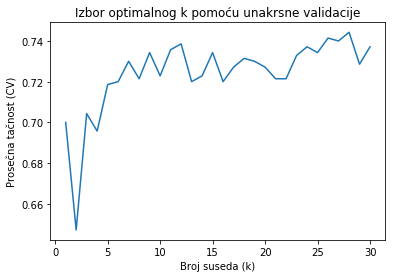

In [20]:
#Vizuelni prikaz tačnost unakrsne validacije u zavisnosti od $k$

import matplotlib.pyplot as plt

plt.figure()
plt.plot(k_values, cv_scores)
plt.xlabel("Broj suseda (k)")
plt.ylabel("Prosečna tačnost unakrsne validacije")
plt.title("Izbor optimalnog k pomoću unakrsne validacije")
plt.show()


In [21]:
#Treniranje finalnog modela sa optimalnim $k$

knn_opt = KNeighborsClassifier(n_neighbors=optimal_k)
knn_opt.fit(X_train_scaled, y_train)

y_pred_opt = knn_opt.predict(X_test_scaled)

print("Test tačnost:", accuracy_score(y_test, y_pred_opt))

Test tačnost: 0.7766666666666666


Optimalna vrednost parametra $k$ identifikovana je primenom unakrsne validacije sa pet podskupova (engl. 5-fold cross-validation) na trening podacima. Izbor je zasnovan na poređenju prosečnih tačnosti svih kandidata, pri čemu je izabrana je vrednost koja je postigla maksimalnu prosečnu validacionu tačnost među svim testiranim kandidatima.

```{admonition} Za one koji žele da znaju više...
:class: seealso


- Osim klasičnih metrika rastojanja, postoje i drugi načini za merenje sličnosti između podataka. U tom smislu, u analizi o ekspresiji gena dobijenih mikročipovima, k-NN algoritam se primenjuje uz korišćenje Pirsonovog i Spirmanovog koeficijenata korelacije, umesto standardnih metrika rastojanja, pogledajte rad [1].

- Iako je naivni KNN algoritam jednostavan za implementaciju, on je računski jako zahtevan, pogotovu za velike skupove podataka, jer se izračunavanju rastojanja između test primera i svakog uzorka u bazi. Da bi se olakšala primena KNN algoritam u praksi, koriste se optimizovani algoritmi za pretragu najbližih suseda koji značajno smanjuju broj potrebnih poređenja, čime se poboljšava efikasnost algoritma čak i pri radu sa velikim brojem podataka. Pogledajte na primer [2], [3], [4].

- U slučaju rada sa bazom podataka sa velikim brojem dimenzija, standardna praksa podrazumeva primenu tehnika za redukciju dimenzionalnosti pre same implementacije k-NN algoritma kako bi se izbeglo prokletstva dimenzionalnosti (engl. curse of dimensionality), [5].

```

Literatura za ovaj deo 

[1] Jaskowiak, P. A.; Campello, R. J. G. B. “Comparing Correlation Coefficients as Dissimilarity Measures
for Cancer Classification in Gene Expression Data”. http://citeseerx.ist.psu.edu/viewdoc/summary?doi=10.1.1.
208.993''. Brazilian Symposium on Bioinformatics (BSB 2011). pp. 1–8. Retrieved 16 October 2014

[2] Weinberger, K. Q., & Saul, L. K. (2009). Distance metric learning for large margin nearest neighbor classification. Journal of machine learning research, 10(2).

[3]  Goldberger, J., Hinton, G. E., Roweis, S., & Salakhutdinov, R. (2004). Neighbourhood components analysis. Advances in Neural Information Processing Systems (NIPS).

[4] Tahir, M. A., Bouridane, A., & Kurugollu, F. (2007). Simultaneous feature selection and feature weighting using Hybrid Tabu Search/K-nearest neighbor classifier. Pattern Recognition Letters, 28(4), 438-446.

[5] Beyer, K., Goldstein, J., Ramakrishnan, R., & Shaft, U. (1999). When Is Nearest Neighbor Meaningful?, Database Theory-ICDT99, 217–235, doi: 10.1007.